Loading county boundaries...
Available columns in county shapefile: ['GEOID10', 'NAME', 'POP_2010', 'AREA_SQKM', 'AREA_SQMI', 'LAND_SQKM', 'WATER_SQKM', 'LAND_SQMI', 'WATER_SQMI', 'STATE_NAME', 'STATE_ABBR', 'STATEFIPS', 'COUNTY', 'Shape_Leng', 'Shape_Area', 'CNTY_FIPS', 'geometry']
Using county name column: COUNTY
Sample county names: ['Grimes', 'Hale', 'Hall', 'Hardin', 'Harris', 'Harrison', 'Hemphill', 'Henderson', 'Hopkins', 'Houston']

Found counties: ['Nueces', 'San Patricio']
Reprojecting counties to UTM 14N...
County CRS after reprojection: EPSG:26914

Processing Fire Station...
  Loaded 62 total Fire Station facilities
  CI CRS: EPSG:32614
  Found 26 Fire Station facilities in target counties
  Columns after spatial join: ['OBJECTID', 'PERMANENT_', 'SOURCE_FEA', 'SOURCE_DAT', 'SOURCE_D_1', 'SOURCE_ORI', 'DATA_SECUR', 'DISTRIBUTI', 'LOADDATE', 'FTYPE', 'FCODE', 'NAME_left', 'ISLANDMARK', 'POINTLOCAT', 'ADMINTYPE', 'ADDRESSBUI', 'ADDRESS', 'CITY', 'STATE', 'ZIPCODE', 'GNIS_ID', 

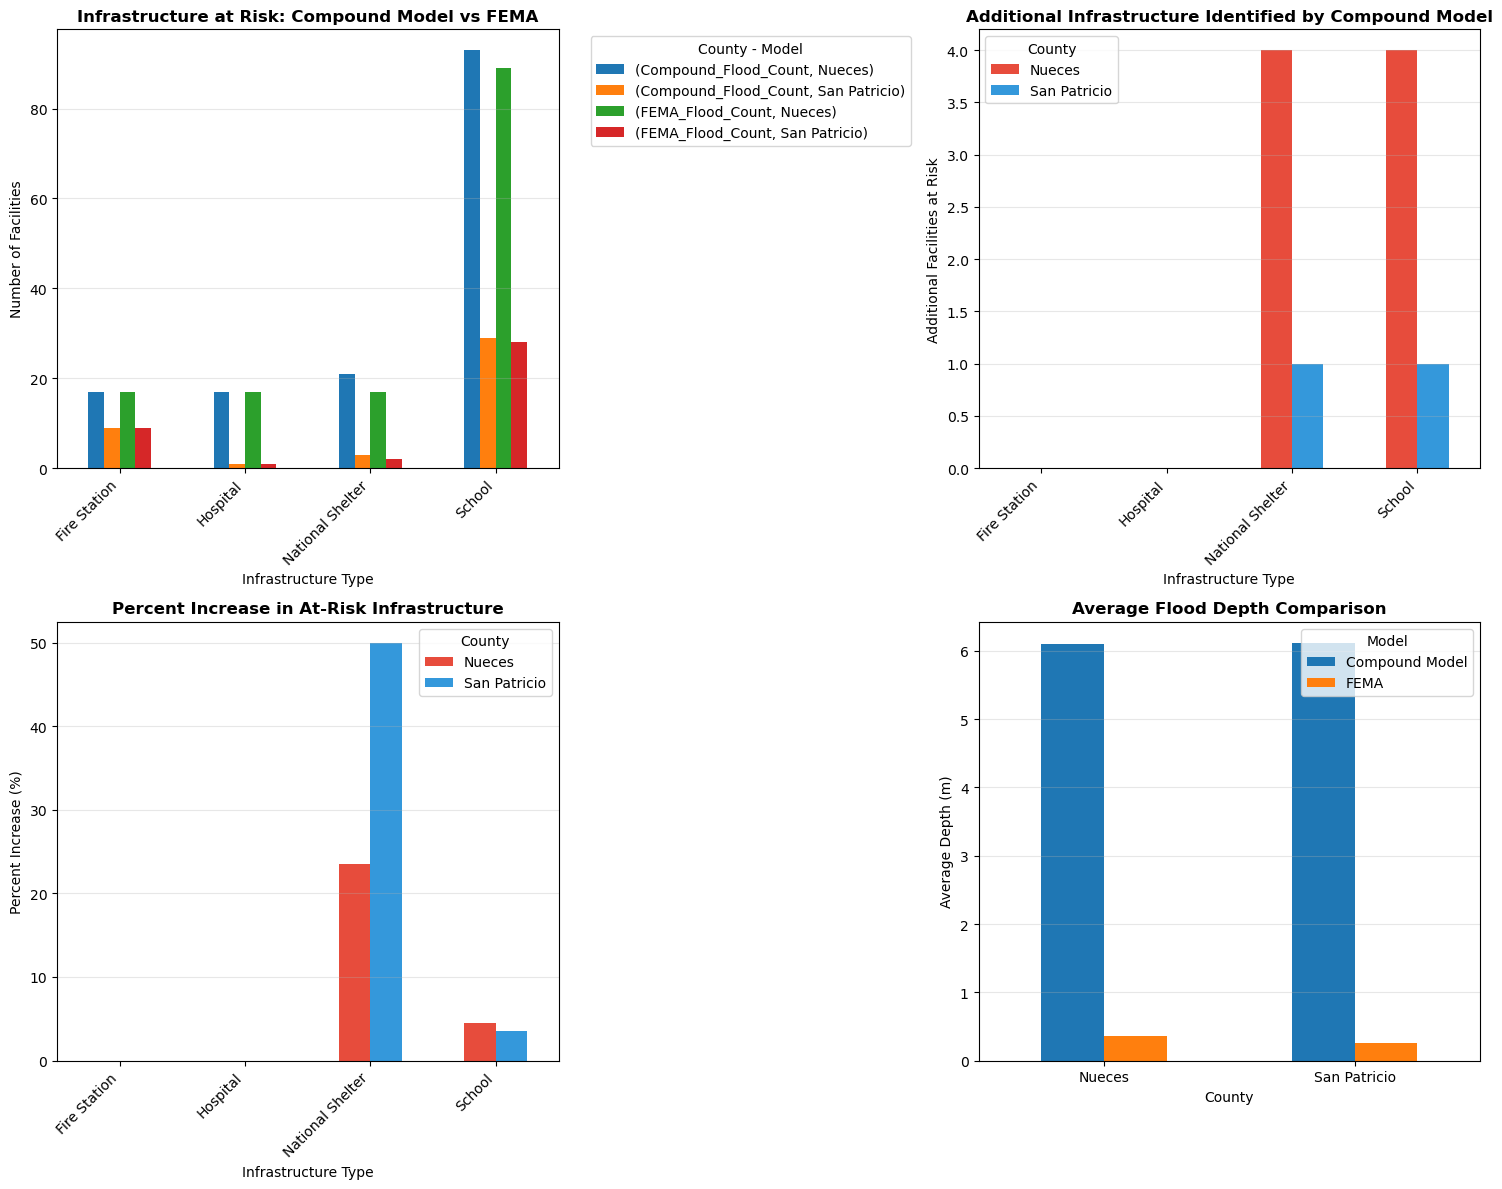


Detailed results saved to 'ci_flood_comparison_results.csv'

ANALYSIS COMPLETE


In [1]:
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import pandas as pd
import numpy as np
from shapely.geometry import Point, mapping
import zipfile
import tempfile
import os
import matplotlib.pyplot as plt
import seaborn as sns

# File paths
county_shapefile = r"D:\Phd Research\Critical Infrastructure\Shape file\Tx_CntyBndry_Detail_TIGER500k.zip"
compound_flood_raster = r"D:\Phd Research\Final_Raster\100yr_compound_flood_base_stat.tif"
fema_flood_raster = r"D:\Phd Research\Final_Raster\Fema_100yr_depth_200m.tif"

ci_paths = {
    "Fire Station": r"D:\Phd Research\GIS\Shape\Critical Infrastructure\Fire_stn_study_area.zip",
    "Hospital": r"D:\Phd Research\GIS\Shape\Critical Infrastructure\hospital_study_area.zip",
    "National Shelter": r"D:\Phd Research\GIS\Shape\Critical Infrastructure\National_shelter_study_area.zip",
    "School": r"D:\Phd Research\GIS\Shape\Critical Infrastructure\School_study_area.shp.zip"
}

# Target counties
target_counties = ["Nueces", "San Patricio"]

def read_shapefile_from_zip(zip_path):
    """Read shapefile from zip archive"""
    with tempfile.TemporaryDirectory() as tmpdir:
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall(tmpdir)
        
        shp_file = [f for f in os.listdir(tmpdir) if f.endswith('.shp')][0]
        gdf = gpd.read_file(os.path.join(tmpdir, shp_file))
    return gdf

def extract_raster_values(points_gdf, raster_path):
    """Extract raster values at point locations"""
    coords = [(point.x, point.y) for point in points_gdf.geometry]
    
    with rasterio.open(raster_path) as src:
        values = []
        for coord in coords:
            try:
                row, col = src.index(coord[0], coord[1])
                if 0 <= row < src.height and 0 <= col < src.width:
                    value = src.read(1)[row, col]
                    # Handle NoData values
                    if value == src.nodata or np.isnan(value):
                        values.append(0)
                    else:
                        values.append(value)
                else:
                    values.append(0)
            except:
                values.append(0)
    
    return values

# Load county boundaries
print("Loading county boundaries...")
counties = read_shapefile_from_zip(county_shapefile)

# Display available columns to identify the correct county name column
print(f"Available columns in county shapefile: {counties.columns.tolist()}")

# Find the county name column
county_name_col = None
for possible_col in ['COUNTY', 'county_par', 'CNTY_NM', 'NAME', 'County', 'NAME10', 'NAMELSAD']:
    if possible_col in counties.columns:
        county_name_col = possible_col
        print(f"Using county name column: {county_name_col}")
        break

if county_name_col is None:
    print("ERROR: Could not find county name column. Please check the shapefile attributes.")
    print(f"Available columns: {counties.columns.tolist()}")
    exit()

# Display sample of county names to verify
print(f"Sample county names: {counties[county_name_col].head(10).tolist()}")

# Filter for target counties
target_counties_gdf = counties[counties[county_name_col].isin(target_counties)].copy()

if len(target_counties_gdf) == 0:
    print(f"\nWARNING: No counties found matching {target_counties}")
    print(f"Please check if county names match exactly. Sample counties in data:")
    print(counties[county_name_col].unique()[:20])
    exit()

print(f"\nFound counties: {target_counties_gdf[county_name_col].tolist()}")

# Reproject to UTM 14N (EPSG:32614 for WGS84 UTM 14N, or EPSG:26914 for NAD83 UTM 14N)
print("Reprojecting counties to UTM 14N...")
target_counties_gdf = target_counties_gdf.to_crs(epsg=26914)  # NAD83 UTM 14N
print(f"County CRS after reprojection: {target_counties_gdf.crs}")

# Load and process critical infrastructure
all_ci_results = []

for ci_type, ci_path in ci_paths.items():
    print(f"\nProcessing {ci_type}...")
    
    try:
        # Load CI data
        ci_gdf = read_shapefile_from_zip(ci_path)
        print(f"  Loaded {len(ci_gdf)} total {ci_type} facilities")
        print(f"  CI CRS: {ci_gdf.crs}")
        
        # Ensure same CRS
        if ci_gdf.crs != target_counties_gdf.crs:
            ci_gdf = ci_gdf.to_crs(target_counties_gdf.crs)
        
        # Spatial join to filter CI within target counties
        ci_in_counties = gpd.sjoin(ci_gdf, target_counties_gdf, how='inner', predicate='within')
        
        if len(ci_in_counties) == 0:
            print(f"  No {ci_type} facilities found in target counties")
            print(f"  Check if county names match. Available columns in counties: {target_counties_gdf.columns.tolist()}")
            continue
        
        print(f"  Found {len(ci_in_counties)} {ci_type} facilities in target counties")
        
        # Check which column contains county names after spatial join
        print(f"  Columns after spatial join: {ci_in_counties.columns.tolist()}")
        
        # Project to appropriate CRS for raster (assuming UTM or similar)
        with rasterio.open(compound_flood_raster) as src:
            raster_crs = src.crs
        
        ci_projected = ci_in_counties.to_crs(raster_crs)
        
        # Extract flood depths
        print(f"  Extracting compound flood depths...")
        ci_projected['compound_depth'] = extract_raster_values(ci_projected, compound_flood_raster)
        
        print(f"  Extracting FEMA flood depths...")
        ci_projected['fema_depth'] = extract_raster_values(ci_projected, fema_flood_raster)
        
        # Define flood threshold (e.g., > 0.1 m to be considered flooded)
        flood_threshold = 0.1
        
        ci_projected['compound_flooded'] = ci_projected['compound_depth'] > flood_threshold
        ci_projected['fema_flooded'] = ci_projected['fema_depth'] > flood_threshold
        ci_projected['additional_risk'] = (ci_projected['compound_flooded']) & (~ci_projected['fema_flooded'])
        
        # Calculate statistics by county
        # Find the county column (will have _right suffix after spatial join)
        county_col = None
        for possible_col in [county_name_col, f'{county_name_col}_right', 'NAME_right', 'CNTY_NM_right']:
            if possible_col in ci_projected.columns:
                county_col = possible_col
                break
        
        if county_col is None:
            print(f"  Warning: Could not find county name column. Available columns: {ci_projected.columns.tolist()}")
            # Try to use the original county column without suffix
            county_col = county_name_col
        
        print(f"  Using county column: {county_col}")
        
        for county in target_counties:
            if county_col not in ci_projected.columns:
                print(f"  Warning: Column {county_col} not found, skipping county statistics")
                break
                
            county_ci = ci_projected[ci_projected[county_col] == county]
            
            if len(county_ci) == 0:
                continue
            
            compound_count = county_ci['compound_flooded'].sum()
            fema_count = county_ci['fema_flooded'].sum()
            additional_count = county_ci['additional_risk'].sum()
            total_count = len(county_ci)
            
            if fema_count > 0:
                percent_increase = (additional_count / fema_count) * 100
            else:
                percent_increase = np.inf if additional_count > 0 else 0
            
            all_ci_results.append({
                'County': county,
                'CI_Type': ci_type,
                'Total_Facilities': total_count,
                'Compound_Flood_Count': compound_count,
                'FEMA_Flood_Count': fema_count,
                'Additional_at_Risk': additional_count,
                'Percent_Increase': percent_increase,
                'Avg_Compound_Depth': county_ci['compound_depth'].mean(),
                'Avg_FEMA_Depth': county_ci['fema_depth'].mean()
            })
    
    except Exception as e:
        print(f"  Error processing {ci_type}: {str(e)}")
        continue

# Create results dataframe
results_df = pd.DataFrame(all_ci_results)

# Check if we have any results
if len(results_df) == 0:
    print("\n" + "="*100)
    print("WARNING: No results generated. Possible issues:")
    print("="*100)
    print("1. No critical infrastructure found in target counties")
    print("2. CRS mismatch between shapefiles and rasters")
    print("3. No overlap between CI locations and flood rasters")
    print("\nDebugging information:")
    print(f"  Counties loaded: {counties.shape[0]}")
    print(f"  Target counties found: {len(target_counties_gdf)}")
    if len(target_counties_gdf) > 0:
        print(f"  County names: {target_counties_gdf[county_name_col].tolist()}")
        print(f"  County CRS: {target_counties_gdf.crs}")
    
    # Try to check raster info
    try:
        with rasterio.open(compound_flood_raster) as src:
            print(f"\n  Compound flood raster CRS: {src.crs}")
            print(f"  Compound flood raster bounds: {src.bounds}")
    except Exception as e:
        print(f"  Error reading compound flood raster: {e}")
    
    print("\nExiting analysis.")
    exit()

# Display detailed results
print("\n" + "="*100)
print("DETAILED RESULTS BY COUNTY AND INFRASTRUCTURE TYPE")
print("="*100)
print(results_df.to_string(index=False))

# Summary statistics
print("\n" + "="*100)
print("SUMMARY STATISTICS")
print("="*100)

for county in target_counties:
    county_data = results_df[results_df['County'] == county]
    
    if len(county_data) == 0:
        continue
    
    print(f"\n{county} County:")
    print(f"  Total CI facilities analyzed: {county_data['Total_Facilities'].sum()}")
    print(f"  Compound flood model identifies at risk: {county_data['Compound_Flood_Count'].sum()}")
    print(f"  FEMA maps identify at risk: {county_data['FEMA_Flood_Count'].sum()}")
    print(f"  Additional facilities at risk (compound - FEMA): {county_data['Additional_at_Risk'].sum()}")
    
    if county_data['FEMA_Flood_Count'].sum() > 0:
        overall_increase = (county_data['Additional_at_Risk'].sum() / 
                          county_data['FEMA_Flood_Count'].sum()) * 100
        print(f"  Overall percent increase: {overall_increase:.1f}%")
    
    print(f"\n  Breakdown by infrastructure type:")
    for _, row in county_data.iterrows():
        if row['FEMA_Flood_Count'] > 0:
            print(f"    {row['CI_Type']}: +{row['Additional_at_Risk']:.0f} facilities "
                  f"({row['Percent_Increase']:.1f}% increase)")
        elif row['Additional_at_Risk'] > 0:
            print(f"    {row['CI_Type']}: +{row['Additional_at_Risk']:.0f} facilities "
                  f"(FEMA identified 0, compound model identified {row['Compound_Flood_Count']:.0f})")

# Visualization
if len(results_df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    
    # Plot 1: Comparison of flooded infrastructure by type and county
    ax1 = axes[0, 0]
    comparison_data = results_df.pivot_table(
        values=['Compound_Flood_Count', 'FEMA_Flood_Count'],
        index='CI_Type',
        columns='County',
        aggfunc='sum',
        fill_value=0
    )
    comparison_data.plot(kind='bar', ax=ax1)
    ax1.set_title('Infrastructure at Risk: Compound Model vs FEMA', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Infrastructure Type')
    ax1.set_ylabel('Number of Facilities')
    ax1.legend(title='County - Model', bbox_to_anchor=(1.05, 1))
    ax1.grid(axis='y', alpha=0.3)
    plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Plot 2: Additional facilities at risk
    ax2 = axes[0, 1]
    additional_data = results_df.pivot_table(
        values='Additional_at_Risk',
        index='CI_Type',
        columns='County',
        aggfunc='sum',
        fill_value=0
    )
    additional_data.plot(kind='bar', ax=ax2, color=['#e74c3c', '#3498db'])
    ax2.set_title('Additional Infrastructure Identified by Compound Model', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Infrastructure Type')
    ax2.set_ylabel('Additional Facilities at Risk')
    ax2.legend(title='County')
    ax2.grid(axis='y', alpha=0.3)
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Plot 3: Percent increase by infrastructure type
    ax3 = axes[1, 0]
    percent_data = results_df[results_df['Percent_Increase'] != np.inf].pivot_table(
        values='Percent_Increase',
        index='CI_Type',
        columns='County',
        aggfunc='mean',
        fill_value=0
    )
    percent_data.plot(kind='bar', ax=ax3, color=['#e74c3c', '#3498db'])
    ax3.set_title('Percent Increase in At-Risk Infrastructure', fontsize=12, fontweight='bold')
    ax3.set_xlabel('Infrastructure Type')
    ax3.set_ylabel('Percent Increase (%)')
    ax3.legend(title='County')
    ax3.grid(axis='y', alpha=0.3)
    plt.setp(ax3.xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # Plot 4: Average flood depths
    ax4 = axes[1, 1]
    depth_comparison = []
    for county in target_counties:
        county_data = results_df[results_df['County'] == county]
        if len(county_data) > 0:
            depth_comparison.append({
                'County': county,
                'Compound Model': county_data['Avg_Compound_Depth'].mean(),
                'FEMA': county_data['Avg_FEMA_Depth'].mean()
            })
    
    if depth_comparison:
        depth_df = pd.DataFrame(depth_comparison)
        depth_df.set_index('County')[['Compound Model', 'FEMA']].plot(kind='bar', ax=ax4)
        ax4.set_title('Average Flood Depth Comparison', fontsize=12, fontweight='bold')
        ax4.set_xlabel('County')
        ax4.set_ylabel('Average Depth (m)')
        ax4.legend(title='Model')
        ax4.grid(axis='y', alpha=0.3)
        plt.setp(ax4.xaxis.get_majorticklabels(), rotation=0)
    
    plt.tight_layout()
    plt.savefig('compound_vs_fema_analysis.png', dpi=300, bbox_inches='tight')
    print(f"\n\nVisualization saved as 'compound_vs_fema_analysis.png'")
    plt.show()

# Save results to CSV
results_df.to_csv('ci_flood_comparison_results.csv', index=False)
print(f"\nDetailed results saved to 'ci_flood_comparison_results.csv'")

print("\n" + "="*100)
print("ANALYSIS COMPLETE")
print("="*100)